# Experiment 1 — ORS vs KL hygiene check

## Why we measure expressivity

A quantum reservoir is a random circuit ensemble $\{U\}$. We say it is
**maximally expressive** when its output states $|\psi_U\rangle = U|0\rangle$
are distributed uniformly over the unit sphere in Hilbert space — i.e. drawn
from the **Haar measure**. Any ensemble that is less expressive is biased
toward some subspace and cannot represent arbitrary functions of the input.

So **expressivity = closeness to Haar**, and the question becomes how to
measure that distance in a scalable way.

---

## The classical baseline: KL divergence on fidelity histograms

Following Sim et al. (2019), one samples many independent state pairs from the
ensemble, computes the fidelities

$$F = |\langle\psi_a | \psi_b\rangle|^2,$$

builds a histogram of the empirical distribution $P_{\text{circuit}}(F)$, and
compares it to the analytical Haar fidelity distribution

$$P_{\text{Haar}}(F) = (D-1)\,(1-F)^{D-2}, \qquad D = 2^n.$$

Closeness to Haar is then quantified by

$$\mathrm{KL}\!\left(P_{\text{circuit}} \,\|\, P_{\text{Haar}}\right).$$

**The problem.** $P_{\text{Haar}}(F)$ is sharply peaked near $F = 0$ with width
$\sim 1/D$. At $n = 12$ that peak has width $\sim 2 \times 10^{-4}$, so resolving it
requires bin widths well below that and far more than $D$ fidelity samples to
populate the bins. KL on fidelities becomes statistically unreliable beyond
$n \approx 8$ — **it does not scale**.

---

## The order-statistics score (ORS, $\Lambda$)

Instead of pairwise fidelities, look at the **sorted output probability
vector** of a single state. For $|\psi_U\rangle$, define
$p_k = |\langle k | \psi_U\rangle|^2$ and sort in descending order:

$$p_{(1)} \geq p_{(2)} \geq \dots \geq p_{(D)}.$$

Each $p_{(k)}$ is the *k*-th **order statistic**. Under Haar, its marginal
density is known in closed form (Micklitz 2025):

$$P_k(x) \propto e^{-k a}\,(1 - e^{-a})^{D-k}, \qquad a = (D-2)\,x.$$

The ORS for one circuit instance is the Haar log-likelihood of the top-$K$
ranks, weighted by $1/k$:

$$\Lambda_s = \sum_{k=1}^{K} \frac{1}{k}\,\log P_k\!\left(p_{(k), s}\right).$$

Averaging over $\mathrm{ns}$ instances gives the ensemble score. **Closer to
the Haar mean → closer to Haar.** Structured ensembles (Clifford, IQP-like)
give scores far below the Haar mean.

### Why this scales when KL does not

| | KL on fidelities | ORS ($\Lambda$) |
|---|---|---|
| Test statistic | full $P(F)$ | top-$K$ sorted $p_{(k)}$ |
| Cost per instance | $O(D)$ | $O(K)$ |
| Sample requirement | $\gg D$ pairs | $\sim 10^2$ instances |
| Scales to $n \geq 10$? | No | Yes |

Two ingredients make the difference. First, the discriminative information
sits in the few largest probabilities; the bulk of $p_{(k)}$ for large $k$ is
floor noise common to every reasonable ensemble. So $K \ll D$ ranks suffice
($K = 50$ by default, capped by support size for stabilizer ensembles).
Second, $\log P_k$ is evaluated analytically at the observed $p_{(k)}$ — no
binning, no bin-width tuning.

---

## What this experiment establishes

We cannot use KL at the scales of interest ($n \geq 10$). We *can* use it at
$n = 6$. The hygiene check is:

> **At $n = 6$, where KL is still reliable, do ORS and KL rank consistently?**

If yes, ORS is a faithful proxy for KL-to-Haar on this regime, and we are
justified in using ORS alone at larger $n$ where KL has broken down. ORS is
not claimed to be *equivalent* to KL — only that the two metrics agree on
which families are more or less Haar-like.


## Step 1: KL Divergence Helpers

These functions implement the KL-divergence expressivity metric from Sim et al. (2019).

- **`fidelity_samples()`** — draws pairs of output states $|\psi_a\rangle, |\psi_b\rangle$ from the ensemble and returns fidelities $F = |\langle\psi_a|\psi_b\rangle|^2$.
- **`haar_fidelity_pdf(F, D)`** — the analytical Haar fidelity distribution $P_{\mathrm{Haar}}(F) = (D-1)(1-F)^{D-2}$, sharply concentrated near $F=0$ with width $\sim 1/D$.
- **`kl_to_haar()`** — bins the empirical fidelity distribution and computes $\mathrm{KL}(P_{\mathrm{circuit}} \| P_{\mathrm{Haar}})$. The histogram approach requires many samples to resolve the narrow Haar peak, which is why KL becomes statistically unreliable beyond $n \approx 8$.

In [ ]:
import numpy as np
from qiskit.quantum_info import Statevector
from tqdm import tqdm

from scipy import linalg
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, random_unitary

from lanczos import FO_state, r_chaometer
from functions_d import k_complexity
import os
from metrics import build_circuit, lorentz_curves, order_statistics_score

def haar_random_circuit(nqbits):
    D = 2 ** nqbits
    U = random_unitary(D).data

    qc = QuantumCircuit(nqbits)
    qc.unitary(U, range(nqbits), label="Haar")

    return qc

def fidelity_samples(circuit_fn, n_states, *, verbose=True):
    """Sample n_states statevectors; return ALL pairwise fidelities."""
    Psi = np.empty((2 ** circuit_fn().num_qubits, n_states), dtype=complex)
    for i in tqdm(range(n_states), disable=not verbose):
        Psi[:, i] = Statevector(circuit_fn()).data
    G = np.abs(Psi.conj().T @ Psi) ** 2          # M x M fidelity matrix
    iu = np.triu_indices(n_states, k=1)          # upper triangle, no diagonal
    return G[iu]

def haar_fidelity_pdf(F, D):
    """Analytical Haar fidelity distribution: P(F) = (D-1) (1-F)^(D-2)."""
    F = np.clip(F, 0.0, 1.0)
    return (D - 1) * (1 - F) ** (D - 2)


def kl_to_haar(fids, D, n_bins=75, eps=1e-12):
    """KL(P_circuit || P_Haar) via histogram of fidelities (Sim et al. 2019).
    
    Both PDFs are evaluated on the same bin grid; KL is summed in probability mass:
        KL = Σ_b p_b log(p_b / q_b)
    where p_b is the empirical bin-mass and q_b is the Haar bin-mass.
    """
    edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    
    # Empirical bin probability mass
    p_emp, _ = np.histogram(fids, bins=edges, density=False)
    p_emp = p_emp.astype(float) / max(len(fids), 1)
    
    # Haar bin probability mass (integrate analytical PDF over each bin via midpoint)
    q_haar = haar_fidelity_pdf(centers, D) * widths
    q_haar /= q_haar.sum()  # renormalise (residual from finite n_bins)
    
    # KL with epsilon guard on both sides
    p_safe = p_emp + eps
    q_safe = q_haar + eps
    p_safe /= p_safe.sum()
    q_safe /= q_safe.sum()
    
    mask = p_emp > 0   # only contribute where empirical mass exists
    return float(np.sum(p_safe[mask] * np.log(p_safe[mask] / q_safe[mask])))

def kl_repeated(circuit_fn, D, n_states, n_bins, n_repeats=5):
    return np.array([
        kl_to_haar(fidelity_samples(circuit_fn, n_states=n_states, verbose=False),
                   D=D, n_bins=n_bins)
        for _ in range(n_repeats)
    ])

print("KL helpers defined.")

KL helpers defined.


## Step 2: Expressivity Sweep — G3 at n=6

We sweep the G3 family (gates drawn from {CNOT, H, T}) over depths $d \in \{2, 5, 10, 20, 50, 100, 200\}$ plus a Haar reference at $n = 6$ qubits ($D = 64$). At this size both KL and ORS are statistically reliable — this is the cross-validation regime.

For each depth we compute:
- **KL divergence** from 1500 statevector samples, repeated 5 times to estimate variance.
- **ORS** $\Lambda$ from 100 circuit instances for $K \in \{1, 2, 4, 8, 16, 32\}$.

Results are cached to `results/ors/results_experiment1.npz` to avoid re-running the sweep.

In [ ]:
# ── Cache file ──────────────────────────────────────────────────────────────
RESULTS_FILE = "results/ors/results_experiment1_krylov.npz"

# ── Load previous results if available ─────────────────────────────────────
if os.path.exists(RESULTS_FILE):
    print(f"Loading cached results from {RESULTS_FILE}")

    loaded = np.load(RESULTS_FILE, allow_pickle=True)
    results = loaded["results"].item()

else:
    print("No cached results found. Running simulations...")

    # ── Sweep configuration ─────────────────────────────────────────────────
    NQBITS       = 6
    D            = 2 ** NQBITS
    NS_ORS       = 100
    N_STATES      = 1500
    N_KL_REPEATS = 5
    K_VALUES     = [1, 2, 4, 8, 16, 32]
    N_BINS_KL    = 75

    # ── Krylov and chaos configuration ─────────────────────────────────────────
    TMAX = 200
    NTIMES = 500
    N_KRYLOV_SAMPLES = 100
    TAIL_AVG = 300
    MAX_FINAL_COMPLEXITY = 500

    families = [
        ("G3 d=2",     "G3",   dict(depth=2)),
        ("G3 d=5",     "G3",   dict(depth=5)),
        ("G3 d=10",    "G3",   dict(depth=10)),
        ("G3 d=20",    "G3",   dict(depth=20)),
        ("G3 d=50",    "G3",   dict(depth=50)),
        ("G3 d=100",   "G3",   dict(depth=100)),
        ("G3 d=200",   "G3",   dict(depth=200)),
        ("Haar",       "Haar", dict(haar_mode="statevector")),
        ("D2 d=1",     "D2_random",   dict(expected_degree=1)),
        ("D2 d=2",     "D2_random",   dict(expected_degree=2)),
        ("D2 d=4",    "D2_random",   dict(expected_degree=4)),
        ("D2 d=6",    "D2_random",   dict(expected_degree=6)),
        ("D2_XZ d=1",    "D2_random_XZ",   dict(expected_degree=1)),
        ("D2_XZ d=2",   "D2_random_XZ",   dict(expected_degree=2)),
        ("D2_XZ d=4",   "D2_random_XZ",   dict(expected_degree=4)),
        ("D2_XZ d=6",    "D2_random_XZ", dict(expected_degree=6)),
    ]
    
    # ── Run sweep ──────────────────────────────────────────────────────────────
    results = {}

    for label, name, kwargs in families:

        print(f"→ {label}")

        fn = build_circuit(name, NQBITS, **kwargs)

        # ORS sampling
        _, sorted_probs, _ = lorentz_curves(
            fn,
            NQBITS,
            nshots=0,
            ns=NS_ORS,
            verbose=False
        )

        # KL repeated evaluations
        kls = kl_repeated(
            fn,
            D=D,
            n_states=N_STATES,
            n_bins=N_BINS_KL,
            n_repeats=N_KL_REPEATS
        )

        # ORS for different K
        ors_by_k = {}

        for K in K_VALUES:
            ors = order_statistics_score(
                sorted_probs,
                D=D,
                K=K
            )

            ors_by_k[K] = {
                "mean": float(np.mean(ors)),
                "std": float(np.std(ors)),
            }

        # Krylov complexity and chaos indicator
        krylov_vals = []
        chaos_vals = []

        ff = np.zeros(D, dtype=complex)
        ff[0] = 1.0

        for _ in range(N_KRYLOV_SAMPLES):

            if name == "Haar":
                qc = haar_random_circuit(NQBITS)
            else:
                qc = fn()

            U = np.asarray(Operator(qc).data, dtype=complex)

            # Effective Hamiltonian from the unitary
            F = -1j * linalg.logm(U)

            # Remove small numerical non-Hermitian components
            F = 0.5 * (F + F.conj().T)

            # Lanczos coefficients
            a, b, c = FO_state(F, ff)

            # Chaos indicator from level spacings
            eigvals = np.sort(np.real(linalg.eigvals(F)))
            chaos_vals.append(r_chaometer(eigvals, False))

            # Krylov complexity
            x, y = k_complexity(
                a,
                b,
                TMAX,
                ntimes=NTIMES
            )

            y = np.real(y)

            if np.isfinite(y[-1]) and y[-1] <= MAX_FINAL_COMPLEXITY:
                krylov_vals.append(np.mean(y[-TAIL_AVG:]))

        krylov_vals = np.array(krylov_vals, dtype=float)
        chaos_vals = np.array(chaos_vals, dtype=float)

        krylov_mean = float(np.nanmean(krylov_vals))
        krylov_std = float(np.nanstd(krylov_vals))

        chaos_mean = float(np.nanmean(chaos_vals))
        chaos_std = float(np.nanstd(chaos_vals))

        results[label] = {
            "ors_by_k": ors_by_k,
            "kl": float(kls.mean()),
            "kl_std": float(kls.std()),
            "kl_runs": kls,

            "krylov": krylov_mean,
            "krylov_std": krylov_std,
            "krylov_runs": krylov_vals,

            "chaos": chaos_mean,
            "chaos_std": chaos_std,
            "chaos_runs": chaos_vals,
        }

        summary = "  ".join(
            f"K={K}: {ors_by_k[K]['mean']:+.2f}"
            for K in K_VALUES
        )

        print(
            f"   KL = {kls.mean():.4f} ± {kls.std():.4f}   "
            f"Krylov = {krylov_mean:.4f} ± {krylov_std:.4f}   "
            f"Chaos = {chaos_mean:.4f} ± {chaos_std:.4f}   "
            f"{summary}"
        )

    # ── Save compressed results ────────────────────────────────────────────────
    np.savez_compressed(
        RESULTS_FILE,
        results=results
    )

    print(f"Results saved to {RESULTS_FILE}")

Loading cached results from results/ors/results_experiment1_krylov.npz


## Calculate exact Haar value for ORS(K)

In [34]:
from metrics import lambda_haar_exact, lambda_haar_largeD

K_ors = 4
nqbits = 6
D = 2 ** nqbits
Lambda_Haar_approx = lambda_haar_largeD(D, K_ors)
Lambda_Haar_exact = lambda_haar_exact(D, K_ors)
print(f"Haar λ (approx) = {Lambda_Haar_approx:.6f}")
print(f"Haar λ (exact)  = {Lambda_Haar_exact:.6f}")

Haar λ (approx) = 5.975389
Haar λ (exact)  = 6.485196


## Step 3: KL vs ORS Comparison Plot

Both metrics are plotted against G3 circuit depth. The left axis (red) shows KL divergence to Haar; each right axis (colour) shows $\Lambda$ for one value of $K$. Dotted horizontal lines mark the respective Haar references ($\mathrm{KL} = 0$; $\Lambda = \Lambda^{\mathrm{Haar}}$).

Both metrics should converge monotonically toward Haar, with the transition occurring in the same depth range $d \in [10, 20]$ across all $K$ — confirming that ORS and KL agree on which families are more or less Haar-like.

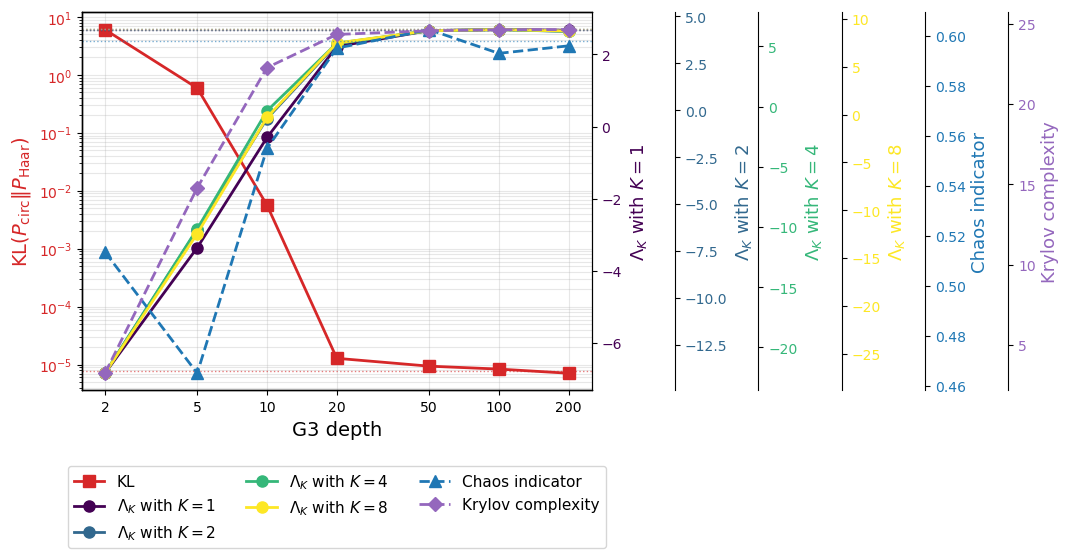

In [35]:
import re
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import ScalarFormatter, NullLocator


def _param_of(label):
    return int(label.split("d=")[1])


def _family_items(results, family):
    """
    Select only the requested family.

    This avoids D2 also matching D2_XZ.
    """
    pattern = re.compile(rf"^{re.escape(family)} d=")

    items = [
        (lab, r)
        for lab, r in results.items()
        if pattern.match(lab)
    ]

    items.sort(key=lambda kv: _param_of(kv[0]))

    return items


def plot_ors_kl_krylov_chaos(
    results,
    family="G3",
    K_VALUES_SMALL=(1, 2, 4, 8),
    title=None,
    plot_krylov = True
):
    # ── Extract data ────────────────────────────────────────────────────────
    items = _family_items(results, family)

    if len(items) == 0:
        raise ValueError(f"No entries found for family {family}")

    haar_item = next(
        ((lab, r) for lab, r in results.items() if lab.startswith("Haar")),
        None
    )

    xvals = np.array([_param_of(lab) for lab, _ in items])

    kl_vals = np.array([r["kl"] for _, r in items])
    chaos_vals = np.array([r["chaos"] for _, r in items])
    krylov_vals = np.array([r["krylov"] for _, r in items])

    # ── Plot ────────────────────────────────────────────────────────────────
    fig, ax_kl = plt.subplots(figsize=(12, 6))

    # KL on primary axis
    kl_color = "tab:red"

    ax_kl.plot(
        xvals,
        kl_vals,
        "s-",
        color=kl_color,
        lw=2,
        ms=8,
        label="KL",
        zorder=5,
    )

    if haar_item is not None:
        ax_kl.axhline(
            haar_item[1]["kl"],
            color=kl_color,
            ls=":",
            lw=1,
            alpha=0.6,
        )

    ax_kl.set_xscale("log")
    ax_kl.set_xticks(xvals)
    ax_kl.get_xaxis().set_major_formatter(ScalarFormatter())
    ax_kl.get_xaxis().set_minor_locator(NullLocator())

    ax_kl.set_yscale("log")

    if family == "G3":
        ax_kl.set_xlabel("G3 depth", fontsize=14)
    else:
        ax_kl.set_xlabel(f"{family} mean degree", fontsize=14)

    ax_kl.set_ylabel(
        r"KL$(P_{\mathrm{circ}} \| P_{\mathrm{Haar}})$",
        color=kl_color,
        fontsize=14,
    )

    ax_kl.tick_params(axis="y", labelcolor=kl_color)
    ax_kl.grid(alpha=0.3, which="both")

    # ORS axes
    axes = []
    handles, labels = ax_kl.get_legend_handles_labels()

    cmap = plt.cm.viridis
    ors_colors = [
        cmap(i / max(len(K_VALUES_SMALL) - 1, 1))
        for i in range(len(K_VALUES_SMALL))
    ]

    offset = 0

    for K, color in zip(K_VALUES_SMALL, ors_colors):
        ax = ax_kl.twinx()
        ax.spines["right"].set_position(("outward", 60 * offset))
        offset += 1

        ors_vals = np.array([
            r["ors_by_k"][K]["mean"]
            for _, r in items
        ])

        ax.plot(
            xvals,
            ors_vals,
            "o-",
            color=color,
            lw=2,
            ms=8,
            label=rf"$\Lambda_K$ with $K={K}$",
        )

        if haar_item is not None:
            haar_ors = haar_item[1]["ors_by_k"][K]["mean"]
            ax.axhline(
                haar_ors,
                color=color,
                ls=":",
                lw=1,
                alpha=0.6,
            )

        ax.set_ylabel(
            rf"$\Lambda_K$ with $K={K}$",
            color=color,
            fontsize=13,
        )
        ax.tick_params(axis="y", labelcolor=color)

        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        axes.append(ax)

    if plot_krylov:
        # Chaos axis
        chaos_color = "tab:blue"

        ax_chaos = ax_kl.twinx()
        ax_chaos.spines["right"].set_position(("outward", 60 * offset))
        offset += 1

        ax_chaos.plot(
            xvals,
            chaos_vals,
            "^-",
            color=chaos_color,
            lw=2,
            ls = '--',
            ms=8,
            label="Chaos indicator",
        )

        if haar_item is not None and "chaos" in haar_item[1]:
            ax_chaos.axhline(
                haar_item[1]["chaos"],
                color=chaos_color,
                ls=":",
                lw=1,
                alpha=0.6,
            )

        ax_chaos.set_ylabel(
            "Chaos indicator",
            color=chaos_color,
            fontsize=13,
        )
        ax_chaos.tick_params(axis="y", labelcolor=chaos_color)

        h, l = ax_chaos.get_legend_handles_labels()
        handles += h
        labels += l

        # Krylov axis
        krylov_color = "tab:purple"

        ax_krylov = ax_kl.twinx()
        ax_krylov.spines["right"].set_position(("outward", 60 * offset))
        offset += 1

        ax_krylov.plot(
            xvals,
            krylov_vals,
            "D-",
            color=krylov_color,
            lw=2,
            ls = '--',
            ms=7,
            label="Krylov complexity",
        )

        if haar_item is not None and "krylov" in haar_item[1]:
            ax_krylov.axhline(
                haar_item[1]["krylov"],
                color=krylov_color,
                ls=":",
                lw=1,
                alpha=0.6,
            )

        ax_krylov.set_ylabel(
            "Krylov complexity",
            color=krylov_color,
            fontsize=13,
        )
        ax_krylov.tick_params(axis="y", labelcolor=krylov_color)

        h, l = ax_krylov.get_legend_handles_labels()
        handles += h
        labels += l

    # Legend and title
    ax_kl.legend(
        handles,
        labels,
        bbox_to_anchor=(0.5, -0.18),
        loc="upper center",
        fontsize=11,
        ncol=3,
    )

    #if title is None:
    #    title = f"KL, ORS, chaos and Krylov comparison for {family}"

    #ax_kl.set_title(title, fontsize=16)

    # Large margin for all right axes
    plt.subplots_adjust(right=0.55, bottom=0.25)

    plt.show()

plot_ors_kl_krylov_chaos(results)

## Step 5: Scalability Demonstration — ORS at n=20

KL divergence is computationally intractable at $n = 20$ ($D = 2^{20} \approx 10^6$), but ORS can be evaluated from a single statevector sample using the `statevector=True` flag.

We compare:
- **G3** ($n = 20$, 1000 gates) — expected near Haar ($\Lambda \approx \Lambda^{\mathrm{Haar}}$).
- **G1** ($n = 20$, 1000 gates) — Clifford-only gate set {CNOT, H, S}, expected far below Haar.

A strongly negative $\Lambda$ score for G1 confirms that ORS discriminates expressivity levels even at qubit sizes where KL is infeasible.

In [38]:
from QELM import QuantumCircQiskit
from metrics import lorentz_curves, order_statistics_score, lambda_haar_largeD
import matplotlib.pyplot as plt
import numpy as np

nqbits = 20
num_gates = 1000
K_ors = 4

qrc = QuantumCircQiskit('G3', nqbits = nqbits, num_gates = num_gates)
cumsum_probs, sorted_probs, _ = lorentz_curves(qrc.get_reservoir, nqbits, 1e7, 1, verbose=True, statevector = True)
lam = order_statistics_score(sorted_probs, 2**nqbits, K=K_ors)[0]

lam_exact = lambda_haar_largeD(2**nqbits, K_ors)
print(f"ORS λ = {lam:.6f}")
print(f"Exact λ = {lam_exact:.6f}")

lorentz_curves: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]

ORS λ = 26.853047
Exact λ = 26.226612


In [39]:
qrc_G1 = QuantumCircQiskit('G1', nqbits = nqbits, num_gates = num_gates)
cumsum_probs_G1, sorted_probs_G1, _ = lorentz_curves(qrc_G1.get_reservoir, nqbits, 1e7, 1, verbose=True, statevector = True)
lam_G1 = order_statistics_score(sorted_probs_G1, 2**nqbits, K=K_ors)[0]

print(f"ORS λ = {lam_G1:.6f}")
print(f"Exact λ = {lam_exact:.6f}")

lorentz_curves: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]

ORS λ = -317585.614564
Exact λ = 26.226612


## Step 6: Noisy ORS Statistic

Hardware circuits are affected by gate errors and readout noise. We model this via a global depolarising fidelity $f \in [0, 1]$, where $f = 1$ is noiseless and $f = 0$ is maximally mixed.

The Haar log-likelihood is replaced by a noise-adapted version $\log P_k^{\mathrm{noisy}}(p_{(k)}, f)$, and the Haar baseline shifts to $\Lambda^{\mathrm{Haar},\mathrm{noisy}}(f)$ (see `lambda_haar_largeD_noisy` in `metrics.py`). The **ORS gap** $\Lambda - \Lambda^{\mathrm{Haar},\mathrm{noisy}}(f)$ remains a valid expressivity measure: a gap of zero means the circuit matches the noise level of a Haar-random circuit at fidelity $f$.

The cells below verify that a G3 circuit (1000 gates, $n=6$) tracks the noisy Haar baseline across $f \in [0.1, 1.0]$, confirming the noise model is internally consistent. IBM hardware results are in `Exp - Quantum Hardware.ipynb`.

In [40]:
from QELM import QuantumCircQiskit
from metrics import lorentz_curves_noisy, order_statistics_score_noisy, lambda_haar_largeD_noisy
import matplotlib.pyplot as plt
import numpy as np

nqbits = 6
num_gates = 1000
K_ors = 4
fs = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
lambdas = []
lambdas_exact = []

qrc = QuantumCircQiskit('G3', nqbits = nqbits, num_gates = num_gates)
for f in fs: 
    cumsum_probs, sorted_probs, _ = lorentz_curves_noisy(qrc.get_reservoir, nqbits, 1e7, 1, fidelity=f, verbose=False, statevector = True)
    lam = order_statistics_score_noisy(sorted_probs, 2**nqbits, K=K_ors, f = f)[0]
    lam_exact = lambda_haar_largeD_noisy(2**nqbits, K_ors, f)
    lambdas.append(lam)
    lambdas_exact.append(lam_exact)
    print(f"f = {f}, λ = {lam:.6f}, λ (exact) = {lam_exact:.6f}")

f = 1.0, λ = 6.733673, λ (exact) = 5.975389
f = 0.9, λ = 6.953174, λ (exact) = 6.194890
f = 0.8, λ = 7.198555, λ (exact) = 6.440272
f = 0.7, λ = 7.476746, λ (exact) = 6.718462
f = 0.6, λ = 7.797893, λ (exact) = 7.039609
f = 0.5, λ = 8.177730, λ (exact) = 7.419446
f = 0.4, λ = 8.642612, λ (exact) = 7.884328
f = 0.3, λ = 9.241950, λ (exact) = 8.483666
f = 0.2, λ = 10.086669, λ (exact) = 9.328385
f = 0.1, λ = 11.530725, λ (exact) = 10.772441


## Multi-basis noisy

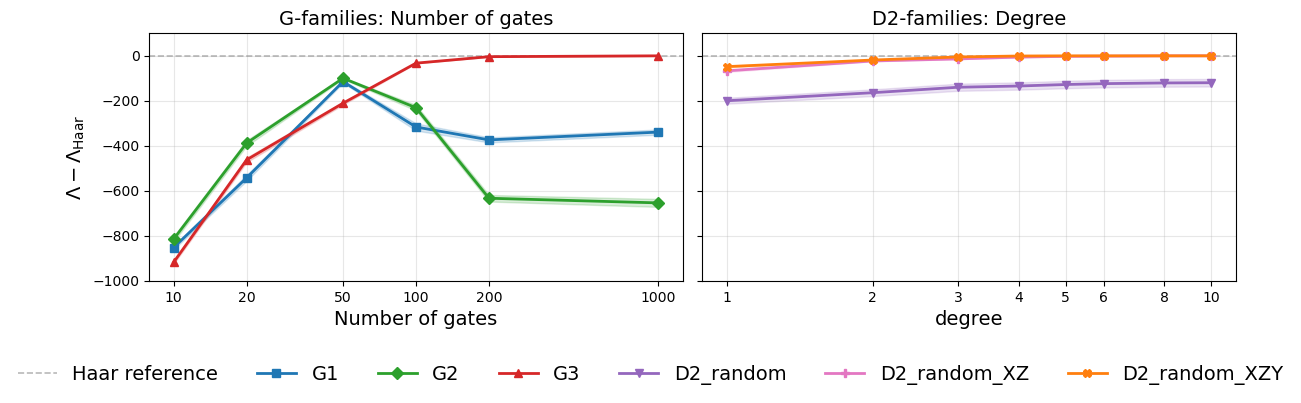

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_OLD = 'results/ors/noisy/'
RESULTS_MB  = 'results/ors/noisy_basis/'

G_FAMILIES  = ['G1', 'G2', 'G3']
D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']

COLORS = {
    'G1': '#1f77b4', 'G2': '#2ca02c', 'G3': '#d62728',
    'D2_random': '#9467bd', 'D2_random_XZ': '#e377c2', 'D2_random_XZY': '#ff7f0e',
}
MARKERS = {
    'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}

G_NUM_GATES = [10, 20, 50, 100, 200, 1000]
D2_DEGREES  = [1, 2, 3, 4, 5, 6, 8, 10]


def ftag(f):
    return f"{float(f):.2f}".replace('.', 'p')


def old_file(fam, kind, val, ns=10, seed=0):
    tag = f"ng{val}" if kind == 'ng' else f"deg{val}_L1"
    return os.path.join(RESULTS_OLD, f"{fam}_{tag}_{ns}runs_seed{seed}.npz")


def mb_file(fam, val, ns=10, seed=1234, basis_seed=4321):
    return os.path.join(
        RESULTS_MB,
        f"{fam}_deg{val}_L1_{ns}runs_seed{seed}_basis{basis_seed}_noise_multibasis.npz"
    )


def load_g_gap(fam, val, n, f, K_idx=3):
    path = old_file(fam, 'ng', val)
    if not os.path.exists(path):
        return np.nan, np.nan

    data = np.load(path)
    ors_key  = f"ors_n{n}_f{ftag(f)}"
    haar_key = f"haar_n{n}_f{ftag(f)}"

    if ors_key not in data.files or haar_key not in data.files:
        return np.nan, np.nan

    vals = data[ors_key][:, K_idx] - data[haar_key][K_idx]
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    return vals.mean(), vals.std() / np.sqrt(len(vals))


def load_d_multibasis_gap(fam, val, n, f, K=8, B=5):
    path = mb_file(fam, val)
    if not os.path.exists(path):
        return np.nan, np.nan

    data = np.load(path)
    ft = ftag(f)

    if "K_ors" in data.files:
        K_list = list(data["K_ors"])
        if K not in K_list:
            raise ValueError(f"K={K} not found in {path}. Available K: {K_list}")
        kidx = K_list.index(K)
    else:
        kidx = 1  # fallback for files with K_ors = [4, 8]

    keys = {
        "X":  f"gap_X_n{n}_f{ft}",
        "Z":  f"gap_Z_n{n}_f{ft}",
        "Y":  f"gap_Y_n{n}_f{ft}",
        "5": f"gmb_B{5}_n{n}_f{ft}",
        "10": f"gmb_B{10}_n{n}_f{ft}",
        "20": f"gmb_B{20}_n{n}_f{ft}",
        "50": f"gmb_B{50}_n{n}_f{ft}",
    }

    if any(k not in data.files for k in keys.values()):
        return np.nan, np.nan

    gaps = np.array([
        abs(data[keys["X"]][kidx]),
        abs(data[keys["Z"]][kidx]),
        abs(data[keys["Y"]][kidx]),
        B*data[keys[str(B)]][kidx],   # already an average absolute gap
    ])
    mean_gap = gaps.sum() / (B + 3)

    return -mean_gap, gaps.std(ddof=1) / np.sqrt((B + 3))


def collect(fam, values, loader, n, f, **kwargs):
    y, e = [], []
    for v in values:
        m, s = loader(fam, v, n, f, **kwargs)
        y.append(m)
        e.append(s)
    return np.array(y), np.array(e)


def plot_ors_complexity_vs_fidelity_multibasis_D(
    n=10,
    fs=(1.0, 0.5, 0.1),
    K_old_idx=3,
    K_mb=8,
    B=5,
    save_path=None,
    ors_floor=-1000.0,
):
    if save_path is None:
        save_path = f'figures/exp2_ORS_noise_n10_multibasis.png'

    fig, axes = plt.subplots(len(fs), 2, figsize=(12, 3.6 * len(fs)), sharey='row')
    axes = np.atleast_2d(axes)

    specs = [
        ('G-families: Number of gates', G_FAMILIES, G_NUM_GATES, 'Number of gates', load_g_gap),
        (rf'D2-families: Degree',
         D2_FAMILIES, D2_DEGREES, 'degree', load_d_multibasis_gap),
    ]

    for r, f in enumerate(fs):
        for c, (title, fams, xs, xlabel, loader) in enumerate(specs):
            ax = axes[r, c]
            ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.55,
                       label='Haar reference' if (r, c) == (0, 0) else None)

            for fam in fams:
                if loader is load_g_gap:
                    y, e = collect(fam, xs, loader, n, f, K_idx=K_old_idx)
                else:
                    y, e = collect(fam, xs, loader, n, f, K=K_mb, B=B)

                y_plot = np.clip(np.where(np.isfinite(y), y, ors_floor), ors_floor, None)

                ax.plot(xs, y_plot, marker=MARKERS[fam], color=COLORS[fam],
                        lw=2.0, label=fam if r == 0 else None)

                mask = np.isfinite(y) & np.isfinite(e)
                if mask.any():
                    ax.fill_between(np.array(xs)[mask],
                                    np.clip(y[mask] - e[mask]/10, ors_floor, None),
                                    y[mask] + e[mask]/10,
                                    color=COLORS[fam], alpha=0.18)

            ax.set_xscale('log')
            ax.set_ylim(ors_floor, -ors_floor * 0.1)
            ax.set_xticks(xs)
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
            ax.get_xaxis().set_minor_locator(plt.NullLocator())
            ax.grid(True, which='both', alpha=0.3)

            if r == 0:
                ax.set_title(title, fontsize=14)
            if r == len(fs) - 1:
                ax.set_xlabel(xlabel, fontsize=14)
            if c == 0:
                ax.set_ylabel(
                    rf'$\Lambda-\Lambda_{{\rm Haar}}$',#  ($f={f}$)',
                    fontsize=14
                )

    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)

    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, -0.01),
               ncol=len(labels), fontsize=14, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


plot_ors_complexity_vs_fidelity_multibasis_D(
    n=10,
    fs=(0.5,),#(1.0, 0.5, 0.1),
    K_old_idx=2,  # old files: usually K in [1,2,4,8]
    K_mb=4,       # new multibasis files: K_ors = [4,8]
    B=5,
)

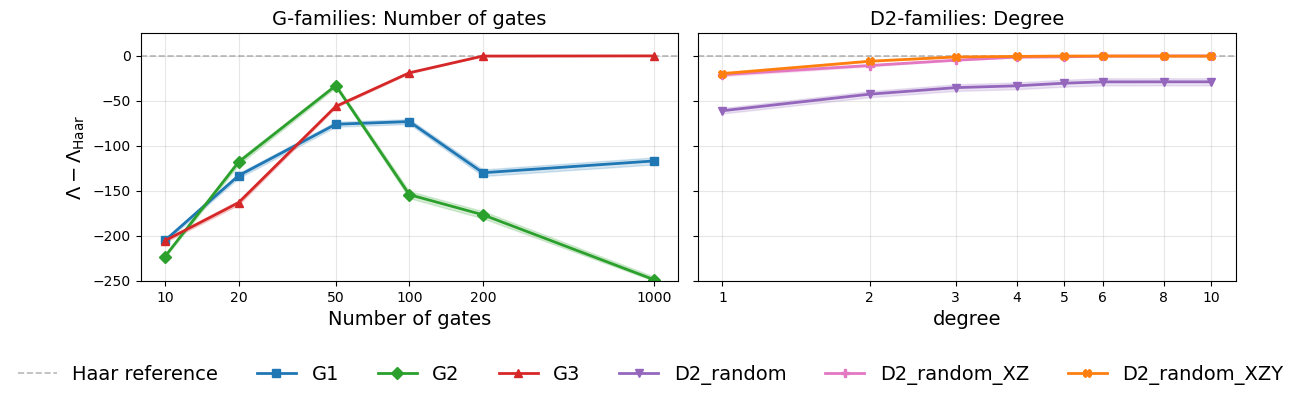

In [52]:
plot_ors_complexity_vs_fidelity_multibasis_D(
    n=8,
    fs=(0.5,),#(1.0, 0.5, 0.1),
    K_old_idx=2,  # old files: usually K in [1,2,4,8]
    K_mb=4,       # new multibasis files: K_ors = [4,8]
    B=5,
    ors_floor=-250,
)

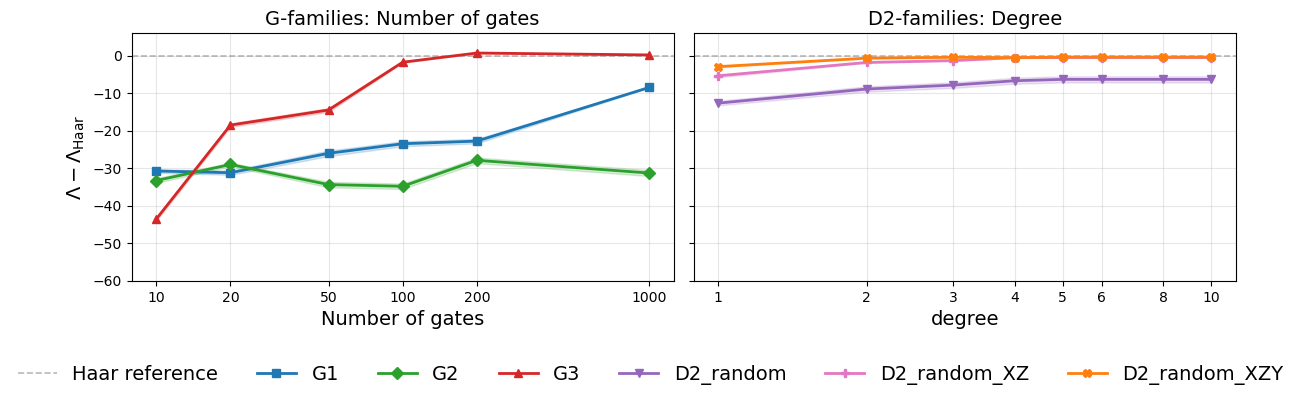

In [55]:
plot_ors_complexity_vs_fidelity_multibasis_D(
    n=6,
    fs=(0.5,),#(1.0, 0.5, 0.1),
    K_old_idx=2,  # old files: usually K in [1,2,4,8]
    K_mb=4,       # new multibasis files: K_ors = [4,8]
    B=5,
    ors_floor=-60,
)